In [1]:
# Esame 654AA - a.a. 2025/2026
# Studenti: Leonardo Celati, Samuele Taviano
# Matricole: 660185, ?

<h1>CUP Datasets SVM</h1>
<p>Exploring the cup dataset with SVM Classifier.</p>
<hr/>

In [2]:
import importlib

import numpy as np
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, mean_absolute_error, mean_squared_error, \
    r2_score
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score, cross_val_predict, KFold
import cup_common as cc
import svm_common as sc
import cross_common as cr

In [3]:
importlib.reload(sc)
importlib.reload(cc)
importlib.reload(cr)

<module 'cross_common' from '/Users/leonardo/workspace/library/source/it.unipi.654AA/notebooks/cross_common.py'>

In [4]:
# Note: The regularization parameter C is explored on a logarithmic scale over four orders of magnitude,
# from strong (0.1) to weak regularization (100), following standard practice for SVM hyperparameter tuning.
param_grid_default = {
    "regressor__estimator__kernel": ["rbf", "linear", "poly", "sigmoid"],
    "regressor__estimator__C": [0.1, 1, 10, 100],
    "regressor__estimator__gamma": ["scale", 0.1, 0.01, 0.001],
    "regressor__estimator__epsilon": [0.01, 0.05, 0.1, 0.2],
    "regressor__estimator__degree": [2, 3, 4],
}

# We only test SVR
pipe_default = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("regressor", MultiOutputRegressor(SVR()))
])

# Common scoring
scoring = cr.common_scoring()

# Common CV fold strategy
cv_common = cr.common_fold_strategy()


<h4>Data Loading</h4>
<p>Load and prepare data</p>

In [5]:
df_train, df_test = cc.load_set()
X_tr, y_tr = cc.prepare_dataset(df_train)
X_ts, y_ts = cc.prepare_dataset(df_test)
features_names = X_tr.columns
cr.dataset_introspection(df_train, df_test)

,Property,Training,Test
0,Number of samples,500,1000
1,Number of features,15,11
2,Class values,[],[]
3,Class balance,[],[]


<h4>Model Selection</h4>
<p>Finding the best model with GridSearchCV.</p>

In [6]:
# Perform a grid search
gs = GridSearchCV(
    estimator = pipe_default,
    param_grid = param_grid_default,
    cv = cv_common,
    scoring = scoring,
    n_jobs = -1 # use all available cores
)

# Fit TR features and labels into grid
gs.fit(X_tr, y_tr)
best_estimator = gs.best_estimator_
best_model, best_params = cr.extract_best_pipeline_metrics_from_grid(gs)
cr.grid_introspection(gs)

Total model explored: 768
Best params: {'regressor__estimator__C': 100, 'regressor__estimator__degree': 2, 'regressor__estimator__epsilon': 0.2, 'regressor__estimator__gamma': 0.1, 'regressor__estimator__kernel': 'rbf'}
Best score: -10.345057764249459
Best model: Pipeline(steps=[('scaler', StandardScaler()),
                ('regressor',
                 MultiOutputRegressor(estimator=SVR(C=100, degree=2,
                                                    epsilon=0.2, gamma=0.1)))])


<h4>Model Assesment</h4>
<p>Collecting various metrics for model assesment.</p>

<h5>Cross-validated prediction</h5>
<p>Cross-validated predictions are computed using a k-fold cross-validation strategy, where the dataset is partitioned into multiple folds and, at each iteration, the model is trained on the training folds and used to predict the held-out fold.
This procedure ensures that each prediction is generated by a model that has not been trained on the corresponding sample, providing an unbiased estimate of the model’s generalization behavior on unseen data.</p>

In [7]:
runner = cr.SklearnRegressorRunner(best_estimator)
kf_result = cr.kfold(runner, X_tr, y_tr, cv_common)

  
Perform fold: 0, train size: 400, val size: 100
Fold summary
--------------------------------------------------------------------------------
Validation MSE  | 201.8393
Validation RMSE | 14.2070
Validation MEE  | 23.9849
Validation MAE  | 10.6716
Train           | samples: 400
Validation      | samples: 100
  
Perform fold: 1, train size: 400, val size: 100
Fold summary
--------------------------------------------------------------------------------
Validation MSE  | 181.5517
Validation RMSE | 13.4741
Validation MEE  | 23.4815
Validation MAE  | 10.3959
Train           | samples: 400
Validation      | samples: 100
  
Perform fold: 2, train size: 400, val size: 100
Fold summary
--------------------------------------------------------------------------------
Validation MSE  | 177.0136
Validation RMSE | 13.3046
Validation MEE  | 23.4375
Validation MAE  | 10.5129
Train           | samples: 400
Validation      | samples: 100
  
Perform fold: 3, train size: 400, val size: 100
Fold summary


In [8]:
importlib.reload(cc)
mean, std = cr.extract_mean_std(kf_result, cc.FOLD_VL_MEE)
print(f"{mean:.4f} ± {std:.4f}")

23.2654 ± 1.0531


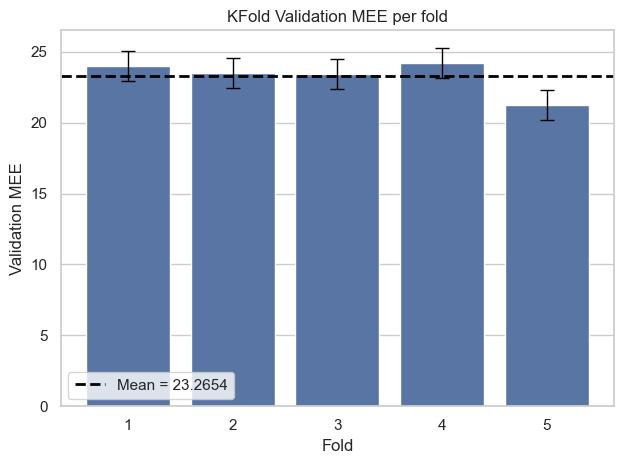

In [9]:
cr.plot_kfold_mee(kf_result)

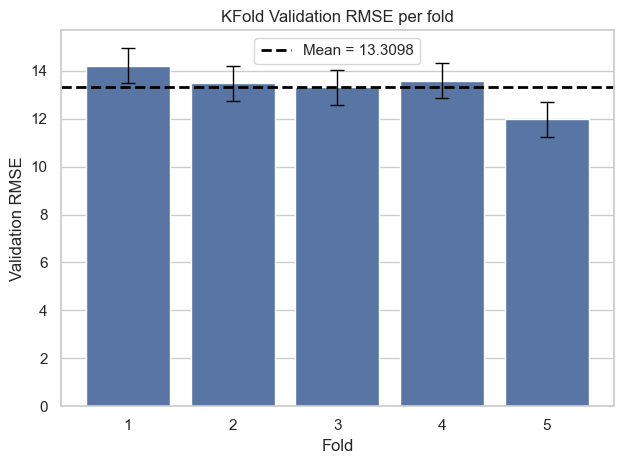

In [10]:
cr.plot_kfold_rmse(kf_result)

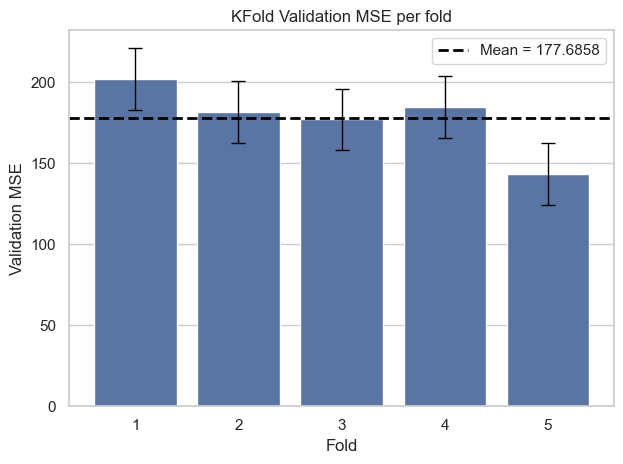

In [11]:
cr.plot_kfold_mse(kf_result)

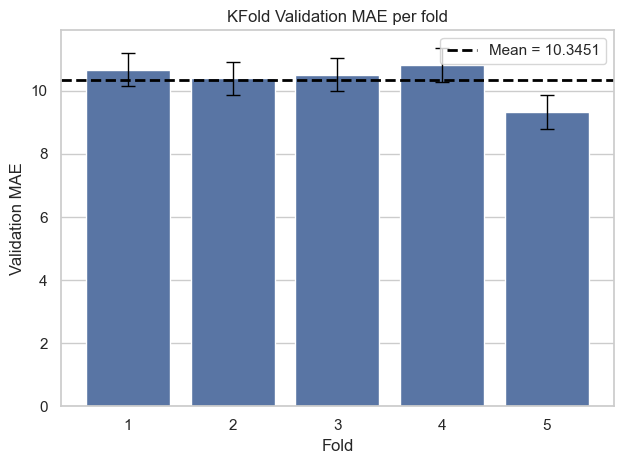

In [12]:
cr.plot_kfold_mae(kf_result)

In [13]:
cr.kfold_regression_table(kf_result, derive_rmse=True)

,TR_MEE,VL_MEE,Gap(TR-VL),TR_RMSE,VL_RMSE
Fold,,,,,
1,19.773098,23.984907,4.211809,4.446695,4.897439
2,20.125868,23.481511,3.355644,4.486186,4.845773
3,19.888241,23.437497,3.549255,4.459623,4.841229
4,19.648648,24.184218,4.535571,4.432680,4.917745
5,20.367172,21.238965,0.871793,4.513000,4.608575
MEAN,19.960605,23.265420,3.304814,4.467637,4.822152
STD,0.287368,1.177357,1.442162,0.032120,0.123838


<h5>Learning Curves</h5>
<p>This plot shows the evolution of training and cross-validation errors as the training set size increases. The learning curve helps assess whether the model suffers from underfitting or overfitting and whether performance is limited by model capacity or by intrinsic noise in the data.</p>

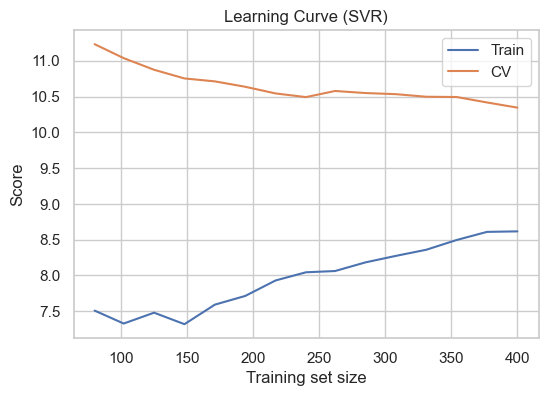

In [14]:
importlib.reload(sc)
sc.plot_learning_curve_svr(best_estimator, X_tr, y_tr, cv_common, scoring=gs.scoring)

<h4>Test predictions</h4>
<p>Test predictions on the test set.</p>

In [15]:
y_pred = best_estimator.predict(X_ts)

In [16]:
print(y_pred)

[[ -2.38738272  -1.17794427   7.56084307  -4.05773067]
 [ -5.87534007   5.74615803 -33.7269309   22.6149831 ]
 [ -5.30597773  -9.73974222  -3.52607161   7.60003837]
 ...
 [ -3.61116456   3.63595657  21.36572376  -8.35175532]
 [  9.00688967  -0.98325326 -21.37452701  25.55960183]
 [ -2.30728735  -2.10446345   7.16022253  -2.22346679]]


<hr/>